In [3]:
# =========================================
# 1. 환경 설정 + CSV 자동 로드
# =========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu, ttest_ind

# -----------------------------
# [그래프 한글 폰트 설정]
# -----------------------------
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# [파일 경로 설정]
# 네 PC 경로 기준
# -----------------------------
PATH_REF50 = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7.csv"
PATH_REF30 = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7_30.csv"

# (참고) 이 환경(채팅)에서 업로드된 파일 경로도 같이 지원
ALT_REF50 = "/mnt/data/refined_h7.csv"
ALT_REF30 = "/mnt/data/refined_h7_30.csv"

def load_csv_fallback(primary_path, alt_path=None, name="data"):
    """
    1) Windows 경로 우선 시도
    2) 실패하면 업로드 경로(/mnt/data) 시도
    """
    for p in [primary_path, alt_path]:
        if p and os.path.exists(p):
            df = pd.read_csv(p, encoding="utf-8-sig")
            print(f"✅ {name} 로드 완료: {p} / shape={df.shape}")
            return df
    raise FileNotFoundError(f"{name} 파일을 찾을 수 없음.\n- {primary_path}\n- {alt_path}")

# 로드
df_ref50_raw = load_csv_fallback(PATH_REF50, ALT_REF50, name="refined_h7 (기본본)")
df_ref30_raw = load_csv_fallback(PATH_REF30, ALT_REF30, name="refined_h7_30 (민감도분석본)")

✅ refined_h7 (기본본) 로드 완료: C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7.csv / shape=(102342, 20)
✅ refined_h7_30 (민감도분석본) 로드 완료: C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7_30.csv / shape=(101373, 20)


In [4]:
# 데이터 표준화/파생변수 보정 함수(누락 대비)

# =========================================
# 2. 데이터 표준화 + 파생변수 보정 함수
# =========================================

def prepare_analysis_df(df_in, name="dataset"):
    df = df_in.copy()

    # -----------------------------
    # [1] 기본 문자열 정리 (공백 제거)
    # -----------------------------
    for c in ["store_group", "day_type", "visit_time"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()

    # -----------------------------
    # [2] 값 표준화 (영문/한글 혼재 대응)
    # -----------------------------
    if "store_group" in df.columns:
        df["store_group"] = df["store_group"].replace({
            "general": "일반",
            "reserve": "리저브",
            "일반 매장": "일반",
            "리저브 매장": "리저브"
        })

    if "day_type" in df.columns:
        df["day_type"] = df["day_type"].replace({
            "weekday": "주중",
            "weekend": "주말"
        })

    if "visit_time" in df.columns:
        df["visit_time"] = df["visit_time"].replace({
            "오전": "아침", "AM": "아침", "am": "아침", "morning": "아침",
            "오후": "점심", "lunch": "점심", "afternoon": "점심",
            "밤": "저녁", "PM": "저녁", "pm": "저녁", "dinner": "저녁", "evening": "저녁"
        })

    # -----------------------------
    # [3] 분석 대상 필터
    # -----------------------------
    if "store_group" in df.columns:
        df = df[df["store_group"].isin(["일반", "리저브"])].copy()

    if "day_type" in df.columns:
        df = df[df["day_type"].isin(["주중", "주말"])].copy()

    if "visit_time" in df.columns:
        df = df[df["visit_time"].isin(["아침", "점심", "저녁"])].copy()

    # -----------------------------
    # [4] 파생변수 없으면 생성 (CSV 상태 대비)
    # -----------------------------
    # 기본축
    if "is_weekday" not in df.columns:
        df["is_weekday"] = (df["day_type"] == "주중").astype(int)
    if "is_weekend" not in df.columns:
        df["is_weekend"] = (df["day_type"] == "주말").astype(int)

    if "is_morning" not in df.columns:
        df["is_morning"] = (df["visit_time"] == "아침").astype(int)
    if "is_lunch" not in df.columns:
        df["is_lunch"] = (df["visit_time"] == "점심").astype(int)
    if "is_evening" not in df.columns:
        df["is_evening"] = (df["visit_time"] == "저녁").astype(int)

    # 6개 조합축
    if "is_weekday_morning" not in df.columns:
        df["is_weekday_morning"] = ((df["day_type"] == "주중") & (df["visit_time"] == "아침")).astype(int)
    if "is_weekday_lunch" not in df.columns:
        df["is_weekday_lunch"] = ((df["day_type"] == "주중") & (df["visit_time"] == "점심")).astype(int)
    if "is_weekday_evening" not in df.columns:
        df["is_weekday_evening"] = ((df["day_type"] == "주중") & (df["visit_time"] == "저녁")).astype(int)

    if "is_weekend_morning" not in df.columns:
        df["is_weekend_morning"] = ((df["day_type"] == "주말") & (df["visit_time"] == "아침")).astype(int)
    if "is_weekend_lunch" not in df.columns:
        df["is_weekend_lunch"] = ((df["day_type"] == "주말") & (df["visit_time"] == "점심")).astype(int)
    if "is_weekend_evening" not in df.columns:
        df["is_weekend_evening"] = ((df["day_type"] == "주말") & (df["visit_time"] == "저녁")).astype(int)

    # -----------------------------
    # [5] 필수 컬럼 체크
    # -----------------------------
    required_cols = [
        "store_id", "store_group", "day_type", "visit_time",
        "is_evening", "is_weekend_evening"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] 필수 컬럼 누락: {missing}")

    print(f"✅ {name} 분석용 정리 완료: {df.shape}")
    return df

# 실제 적용
df50 = prepare_analysis_df(df_ref50_raw, name="refined_h7 (기본본)")
df30 = prepare_analysis_df(df_ref30_raw, name="refined_h7_30 (민감도분석본)")

✅ refined_h7 (기본본) 분석용 정리 완료: (102342, 20)
✅ refined_h7_30 (민감도분석본) 분석용 정리 완료: (101373, 20)


In [61]:
# =========================================
# 3. 기본 검문소 (분석 전 체크)
# =========================================

def precheck_summary(df, name="dataset"):
    print("="*70)
    print(f"[{name}] 기본 검문소")
    print("="*70)

    # 1) shape
    print("\n1) 데이터 크기")
    print(df.shape)

    # 2) 핵심 범주 분포
    print("\n2) store_group 분포")
    print(df["store_group"].value_counts(dropna=False))

    print("\n3) day_type 분포")
    print(df["day_type"].value_counts(dropna=False))

    print("\n4) visit_time 분포")
    print(df["visit_time"].value_counts(dropna=False))

    # 3) 결측 확인
    check_cols = ["store_id", "store_group", "day_type", "visit_time", "is_evening", "is_weekend_evening"]
    print("\n5) 핵심 컬럼 결측")
    print(df[check_cols].isna().sum())

    # 4) 0/1 파생변수 평균 = 전체 비중
    ratio_cols = [
        "is_weekday", "is_weekend",
        "is_morning", "is_lunch", "is_evening",
        "is_weekday_morning", "is_weekday_lunch", "is_weekday_evening",
        "is_weekend_morning", "is_weekend_lunch", "is_weekend_evening"
    ]
    ratio_cols = [c for c in ratio_cols if c in df.columns]

    print("\n6) 파생변수 평균(=전체 비중 %)")
    print((df[ratio_cols].mean() * 100).round(2).astype(str) + "%")

# 실행
precheck_summary(df50, "기본본(50개 제한)")
precheck_summary(df30, "민감도본(30개 기준)")

[기본본(50개 제한)] 기본 검문소

1) 데이터 크기
(102342, 20)

2) store_group 분포
store_group
일반     99212
리저브     3130
Name: count, dtype: int64

3) day_type 분포
day_type
주중    68698
주말    33644
Name: count, dtype: int64

4) visit_time 분포
visit_time
점심    62716
저녁    23467
아침    16159
Name: count, dtype: int64

5) 핵심 컬럼 결측
store_id              0
store_group           0
day_type              0
visit_time            0
is_evening            0
is_weekend_evening    0
dtype: int64

6) 파생변수 평균(=전체 비중 %)
is_weekday            67.13%
is_weekend            32.87%
is_morning            15.79%
is_lunch              61.28%
is_evening            22.93%
is_weekday_morning    11.47%
is_weekday_lunch      40.18%
is_weekday_evening    15.48%
is_weekend_morning     4.32%
is_weekend_lunch       21.1%
is_weekend_evening     7.45%
dtype: str
[민감도본(30개 기준)] 기본 검문소

1) 데이터 크기
(101373, 20)

2) store_group 분포
store_group
일반     98243
리저브     3130
Name: count, dtype: int64

3) day_type 분포
day_type
주중    68003
주말    33370
Name: 

In [7]:
# [검정 전 확인 사항]
# 1) 분석 대상 변수 유형 확인
#    - H7-0(카이제곱): store_group(범주형) × slot_6(범주형) -> 적합
#    - H7-1/H7-2(비율검정): is_evening, is_weekend_evening (0/1) -> 적합

# 2) 표본 구조 확인
#    - 리뷰 단위(row-level) 분석이므로 같은 매장 리뷰가 여러 개 포함됨
#    - 완전한 독립표본 가정은 약할 수 있음
#    - 따라서 p값 해석은 보수적으로 하고, 매장 단위 보강 분석을 추가 수행

# 3) 카이제곱 검정 전제조건
#    - 기대빈도(expected frequency) 너무 작은 칸이 많은지 확인 (일반적으로 5 이상 권장)

# 4) 비율검정 전제조건
#    - 각 그룹에서 성공/실패 개수가 충분한지 확인 (정규근사 가능 여부)
#    - 보통 성공/실패가 각 5 이상이면 안전

In [62]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# =========================================
# 4. H7-0 카이제곱 독립성 검정 (전체 분포 차이)
#  - + 효과크기(Cramér's V) 추가
#  - + p-value 소수/과학적 표기 둘 다 출력
#  - + 표준화 잔차(residual) 반환(히트맵에 바로 사용)
# =========================================

def chi_square_test_slot6(df, name="dataset", alpha=0.05, verbose=True):
    """
    H7-0: 일반/리저브의 방문 패턴 분포(주중/주말 × 시간대)가 동일하지 않다
    검정: 카이제곱 '독립성' 검정 (Chi-square test of independence)

    왜 독립성 검정?
    - store_group(일반/리저브) : 범주형
    - slot_6(주중/주말×시간대 6칸) : 범주형
    => 범주형×범주형 분포 차이(독립성) 검정이므로 카이제곱 독립성 검정이 적합

    반환:
    - ct(관측 분할표), expected(기대도수), resid(표준화 잔차), chi2/p/dof, cramers_v(효과크기)
    """

    d = df.copy()

    # -----------------------------
    # 0) 값 표준화 (혹시 영문/공백 섞여도 안전)
    # -----------------------------
    d["store_group"] = d["store_group"].astype(str).str.strip().replace({
        "general": "일반", "reserve": "리저브",
        "일반 매장": "일반", "리저브 매장": "리저브"
    })
    d["day_type"] = d["day_type"].astype(str).str.strip().replace({
        "weekday": "주중", "weekend": "주말"
    })
    d["visit_time"] = d["visit_time"].astype(str).str.strip().replace({
        "오전":"아침","AM":"아침","am":"아침","morning":"아침",
        "오후":"점심","lunch":"점심","afternoon":"점심",
        "밤":"저녁","PM":"저녁","pm":"저녁","dinner":"저녁","evening":"저녁"
    })

    # 분석에 필요한 값만 남기기
    d = d[d["store_group"].isin(["일반", "리저브"])].copy()
    d = d[d["day_type"].isin(["주중", "주말"])].copy()
    d = d[d["visit_time"].isin(["아침", "점심", "저녁"])].copy()

    # -----------------------------
    # 1) slot_6 생성
    # -----------------------------
    d["slot_6"] = d["day_type"] + "_" + d["visit_time"]

    slot_order = ["주중_아침", "주중_점심", "주중_저녁",
                  "주말_아침", "주말_점심", "주말_저녁"]

    # -----------------------------
    # 2) 관측 분할표(Observed)
    # -----------------------------
    ct = pd.crosstab(d["store_group"], d["slot_6"]).reindex(
        index=["일반", "리저브"],
        columns=slot_order,
        fill_value=0
    )

    # -----------------------------
    # 3) 카이제곱 독립성 검정
    # -----------------------------
    chi2, p, dof, expected = chi2_contingency(ct)
    expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

    # -----------------------------
    # 4) 전제조건(기대도수) 체크
    # -----------------------------
    min_expected = float(expected_df.min().min())
    small_cells = int((expected_df < 5).sum().sum())
    total_cells = int(expected_df.size)

    # -----------------------------
    # 5) 표준화 잔차(히트맵용)
    #   resid = (O - E) / sqrt(E)
    # -----------------------------
    resid_df = (ct - expected_df) / np.sqrt(expected_df)

    # -----------------------------
    # 6) 효과크기: Cramér's V
    #   V = sqrt( chi2 / (n * min(r-1, c-1)) )
    # -----------------------------
    n = ct.to_numpy().sum()
    r, c = ct.shape
    cramers_v = float(np.sqrt(chi2 / (n * min(r - 1, c - 1))))

    # -----------------------------
    # 7) 출력 (발표용)
    # -----------------------------
    if verbose:
        print("="*75)
        print(f"[{name}] H7-0 카이제곱 독립성 검정 (store_group × slot_6)")
        print("="*75)

        print("\n[관측 분할표 O]")
        print(ct)

        # p-value 두 형식
        p_dec = f"{float(p):.12f}"
        p_sci = f"{float(p):.2e}"

        print("\n[검정 결과]")
        print(f"chi2 = {chi2:.4f}")
        print(f"dof  = {dof}  (= (2-1)*(6-1)=5)")
        print(f"p-value(소수) = {p_dec}")
        print(f"p-value(과학적) = {p_sci}")
        print(f"Cramér's V(효과크기) = {cramers_v:.3f}")

        print("\n[전제조건 점검: 기대도수 E]")
        print(f"최소 기대도수 = {min_expected:.3f}")
        print(f"기대도수 5 미만 셀 수 = {small_cells}/{total_cells}")

        print("\n[결론]")
        if p < alpha:
            print("✅ H7-0 지지: 일반/리저브의 방문 패턴 분포(주중·주말×시간대)는 유의하게 다름")
        else:
            print("❌ H7-0 미지지: 전체 분포 차이가 유의하다고 보기 어려움")

        # 잔차 최대칸(어느 슬롯이 차이를 주도?)
        max_idx = np.unravel_index(np.abs(resid_df.to_numpy()).argmax(), resid_df.shape)
        max_row = resid_df.index[max_idx[0]]
        max_col = resid_df.columns[max_idx[1]]
        max_val = float(resid_df.iloc[max_idx])
        print(f"\n[차이를 크게 만든 셀(표준화 잔차 |최대|)] {max_row} × {max_col} : {max_val:+.2f}")

    return {
        "name": name,
        "ct": ct,                      # 관측도수 O
        "expected": expected_df,        # 기대도수 E
        "resid": resid_df,              # 표준화 잔차
        "chi2": float(chi2),
        "p": float(p),
        "dof": int(dof),
        "cramers_v": cramers_v,
        "min_expected": min_expected,
        "small_cells": small_cells,
        "n_total": int(n)
    }

# 실행 (기본본 + 민감도본)
# df50, df30이 이미 있으면 그대로 쓰고,
# 없으면 refined_h7.csv/refined_h7_30.csv를 로드해서 df50/df30로 만들어도 됨.
chi50 = chi_square_test_slot6(df50, name="기본본(50개 제한)")
chi30 = chi_square_test_slot6(df30, name="민감도본(30개 기준)")

[기본본(50개 제한)] H7-0 카이제곱 독립성 검정 (store_group × slot_6)

[관측 분할표 O]
slot_6       주중_아침  주중_점심  주중_저녁  주말_아침  주말_점심  주말_저녁
store_group                                          
일반           11438  39840  15319   4287  20975   7353
리저브            296   1281    524    138    620    271

[검정 결과]
chi2 = 24.0661
dof  = 5  (= (2-1)*(6-1)=5)
p-value(소수) = 0.000210850350
p-value(과학적) = 2.11e-04
Cramér's V(효과크기) = 0.015

[전제조건 점검: 기대도수 E]
최소 기대도수 = 135.333
기대도수 5 미만 셀 수 = 0/12

[결론]
✅ H7-0 지지: 일반/리저브의 방문 패턴 분포(주중·주말×시간대)는 유의하게 다름

[차이를 크게 만든 셀(표준화 잔차 |최대|)] 리저브 × 주중_아침 : -3.32
[민감도본(30개 기준)] H7-0 카이제곱 독립성 검정 (store_group × slot_6)

[관측 분할표 O]
slot_6       주중_아침  주중_점심  주중_저녁  주말_아침  주말_점심  주말_저녁
store_group                                          
일반           11282  39410  15210   4245  20792   7304
리저브            296   1281    524    138    620    271

[검정 결과]
chi2 = 23.2782
dof  = 5  (= (2-1)*(6-1)=5)
p-value(소수) = 0.000298634077
p-value(과학적) = 2.99e-04
Cramér's V(효과크기) = 0.015

[전제조건 점검: 기대도수

H7-1 검정: 리저브 매장은 일반 대비 '저녁 비중'이 더 높다
일반:  저녁 22672/99212 = 22.85%
리저브: 저녁 795/3130 = 25.40%
차이(리저브-일반) = 2.55%p  ← (크기 차이)
z = 3.3378
p-value(고정) = 0.000422219481009
p-value(과학적) = 4.222194810087e-04
✅ 결론: H7-1 지지 (리저브가 일반보다 저녁 비중이 '유의하게' 높음)


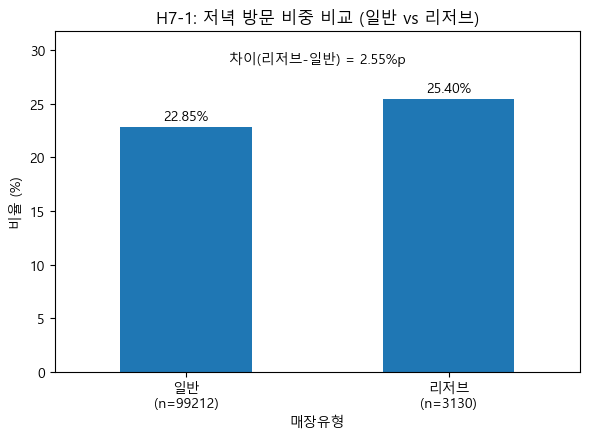

In [70]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import platform

# 한글 폰트 (그래프용)
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

def h7_1_evening_prop_test(df, group_col="store_group", alpha=0.05, show_plot=True):
    d = df.copy()

    # store_group 표준화
    d[group_col] = d[group_col].astype(str).str.strip().replace({
        "general": "일반", "reserve": "리저브",
        "일반 매장": "일반", "리저브 매장": "리저브"
    })

    # is_evening 없으면 생성
    if "is_evening" not in d.columns:
        if "visit_time" not in d.columns:
            raise KeyError("is_evening도 없고 visit_time도 없음.")
        d["visit_time"] = d["visit_time"].astype(str).str.strip().replace({
            "오전":"아침","AM":"아침","am":"아침","morning":"아침",
            "오후":"점심","lunch":"점심","afternoon":"점심",
            "밤":"저녁","PM":"저녁","pm":"저녁","dinner":"저녁","evening":"저녁"
        })
        d["is_evening"] = (d["visit_time"] == "저녁").astype(int)

    # 그룹별 성공수/전체수
    agg = d.groupby(group_col)["is_evening"].agg(["sum", "count"]).reindex(["일반", "리저브"])
    if agg.isna().any().any():
        raise ValueError("일반/리저브 그룹 매핑 실패. store_group 값 확인 필요.")

    succ_gen = float(agg.loc["일반", "sum"])
    n_gen    = float(agg.loc["일반", "count"])
    succ_res = float(agg.loc["리저브", "sum"])
    n_res    = float(agg.loc["리저브", "count"])

    # 비율/차이
    p_gen = succ_gen / n_gen
    p_res = succ_res / n_res
    diff_pp = (p_res - p_gen) * 100

    # 2표본 비율검정 (단측: 리저브 > 일반)
    z_stat, p_one = proportions_ztest(
        count=np.array([succ_res, succ_gen], dtype=float),
        nobs=np.array([n_res, n_gen], dtype=float),
        alternative="larger"
    )

    # 출력
    print("="*75)
    print("H7-1 검정: 리저브 매장은 일반 대비 '저녁 비중'이 더 높다")
    print("="*75)
    print(f"일반:  저녁 {int(succ_gen)}/{int(n_gen)} = {p_gen*100:.2f}%")
    print(f"리저브: 저녁 {int(succ_res)}/{int(n_res)} = {p_res*100:.2f}%")
    print(f"차이(리저브-일반) = {diff_pp:.2f}%p  ← (크기 차이)")
    print(f"z = {float(z_stat):.4f}")
    print(f"p-value(고정) = {float(p_one):.15f}")
    print(f"p-value(과학적) = {float(p_one):.12e}")

    if p_one < alpha and diff_pp > 0:
        print("✅ 결론: H7-1 지지 (리저브가 일반보다 저녁 비중이 '유의하게' 높음)")
    elif diff_pp > 0:
        print("⚠️ 결론: 리저브가 더 높긴 하지만 유의하다고 보기 어려움(경향)")
    else:
        print("❌ 결론: 가설 반대(리저브 ≤ 일반)")

    # 그래프
    if show_plot:
        plot_s = pd.Series({
            f"일반\n(n={int(n_gen)})": p_gen*100,
            f"리저브\n(n={int(n_res)})": p_res*100
        })
        ax = plot_s.plot(kind="bar", figsize=(6,4.5), rot=0)
        plt.title("H7-1: 저녁 방문 비중 비교 (일반 vs 리저브)")
        plt.ylabel("비율 (%)")
        plt.xlabel("매장유형")

        ymax = plot_s.max()
        ax.set_ylim(0, ymax * 1.25 if ymax > 0 else 1)

        for p_ in ax.patches:
            h = p_.get_height()
            ax.annotate(f"{h:.2f}%",
                        (p_.get_x() + p_.get_width()/2, h),
                        ha="center", va="bottom", fontsize=10,
                        xytext=(0,3), textcoords="offset points")

        plt.text(0.5, ymax * 1.15, f"차이(리저브-일반) = {diff_pp:.2f}%p",
                 ha="center", va="center", fontsize=10)
        plt.tight_layout()
        plt.show()

    return {
        "general_rate_pct": round(p_gen*100, 2),
        "reserve_rate_pct": round(p_res*100, 2),
        "diff_pp": round(diff_pp, 2),
        "z": float(z_stat),
        "p_one": float(p_one),
        "n_general": int(n_gen),
        "n_reserve": int(n_res)
    }

result_h7_1 = h7_1_evening_prop_test(df50, show_plot=True)

H7-1: 리저브는 일반 대비 저녁 방문 비중이 더 높다 (2표본 비율검정, 단측)
일반  : 22672/99212 = 22.85%
리저브: 795/3130 = 25.40%
차이(리저브-일반) = 2.55%p
z = 3.3378
p-value(고정)   = 0.000422219481009
p-value(과학적) = 4.222194810087e-04  (***)
✅ 결론: H7-1 지지 (리저브 > 일반, 유의)


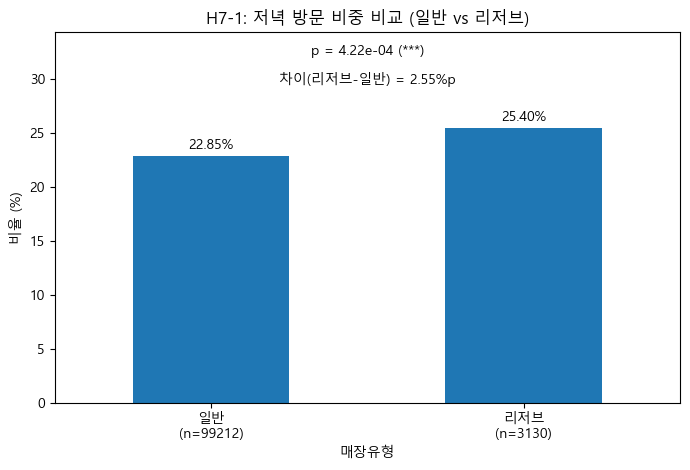

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

def h7_1_evening_prop_test_clean(df, group_col="store_group", alpha=0.05, show_plot=True):
    """
    H7-1: 리저브 매장은 일반 매장 대비 '저녁 방문 비중'이 더 높다.
    - 2표본 비율검정(단측: 리저브 > 일반)
    - 출력: 비율(%) + 차이(%p) + p-value(고정/과학적) + 그래프(텍스트로 p표시)
    """

    d = df.copy()

    # store_group 표준화
    d[group_col] = d[group_col].astype(str).str.strip().replace({
        "general": "일반", "reserve": "리저브",
        "일반 매장": "일반", "리저브 매장": "리저브"
    })

    # is_evening 없으면 생성
    if "is_evening" not in d.columns:
        if "visit_time" not in d.columns:
            raise KeyError("is_evening도 없고 visit_time도 없음.")
        d["visit_time"] = d["visit_time"].astype(str).str.strip().replace({
            "오전":"아침","AM":"아침","am":"아침","morning":"아침",
            "오후":"점심","lunch":"점심","afternoon":"점심",
            "밤":"저녁","PM":"저녁","pm":"저녁","dinner":"저녁","evening":"저녁"
        })
        d["is_evening"] = (d["visit_time"] == "저녁").astype(int)

    # 집단별 성공수/전체수
    agg = d.groupby(group_col)["is_evening"].agg(["sum", "count"]).reindex(["일반", "리저브"])
    if agg.isna().any().any():
        raise ValueError("일반/리저브 그룹 매핑 실패. store_group 값 확인 필요.")

    succ_gen = float(agg.loc["일반", "sum"]); n_gen = float(agg.loc["일반", "count"])
    succ_res = float(agg.loc["리저브", "sum"]); n_res = float(agg.loc["리저브", "count"])

    p_gen = succ_gen / n_gen
    p_res = succ_res / n_res
    diff_pp = (p_res - p_gen) * 100

    # 2표본 비율검정 (단측: 리저브 > 일반)
    z_stat, p_one = proportions_ztest(
        count=np.array([succ_res, succ_gen], dtype=float),
        nobs=np.array([n_res, n_gen], dtype=float),
        alternative="larger"
    )
    p_one = float(p_one)

    # 별표
    def p_to_stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "n.s."

    stars = p_to_stars(p_one)

    # 콘솔 출력
    print("="*75)
    print("H7-1: 리저브는 일반 대비 저녁 방문 비중이 더 높다 (2표본 비율검정, 단측)")
    print("="*75)
    print(f"일반  : {int(succ_gen)}/{int(n_gen)} = {p_gen*100:.2f}%")
    print(f"리저브: {int(succ_res)}/{int(n_res)} = {p_res*100:.2f}%")
    print(f"차이(리저브-일반) = {diff_pp:.2f}%p")
    print(f"z = {float(z_stat):.4f}")
    print(f"p-value(고정)   = {p_one:.15f}")
    print(f"p-value(과학적) = {p_one:.12e}  ({stars})")

    if p_one < alpha and diff_pp > 0:
        print("✅ 결론: H7-1 지지 (리저브 > 일반, 유의)")
    elif diff_pp > 0:
        print("⚠️ 결론: 리저브가 더 높지만 유의하지 않음(경향)")
    else:
        print("❌ 결론: 가설 반대(리저브 ≤ 일반)")

    # 그래프(비율 비교 + p값 텍스트만)
    if show_plot:
        plot_s = pd.Series({
            f"일반\n(n={int(n_gen)})": p_gen*100,
            f"리저브\n(n={int(n_res)})": p_res*100
        })

        ax = plot_s.plot(kind="bar", figsize=(7, 4.8), rot=0)
        plt.title("H7-1: 저녁 방문 비중 비교 (일반 vs 리저브)")
        plt.ylabel("비율 (%)")
        plt.xlabel("매장유형")

        ymax = plot_s.max()
        ax.set_ylim(0, ymax * 1.35 if ymax > 0 else 1)

        # 막대 라벨
        for p_ in ax.patches:
            h = p_.get_height()
            ax.annotate(f"{h:.2f}%",
                        (p_.get_x() + p_.get_width()/2, h),
                        ha="center", va="bottom", fontsize=10,
                        xytext=(0,3), textcoords="offset points")

        # 차이/유의성 텍스트(그래프 위)
        plt.text(0.5, ymax * 1.18, f"차이(리저브-일반) = {diff_pp:.2f}%p",
                 ha="center", va="center", fontsize=10)
        plt.text(0.5, ymax * 1.28, f"p = {p_one:.2e} ({stars})",
                 ha="center", va="center", fontsize=10)

        plt.tight_layout()
        plt.show()

    return {
        "general_rate_pct": round(p_gen*100, 2),
        "reserve_rate_pct": round(p_res*100, 2),
        "diff_pp": round(diff_pp, 2),
        "z": float(z_stat),
        "p_one": p_one,
        "stars": stars,
        "n_general": int(n_gen),
        "n_reserve": int(n_res)
    }

# 실행
result_h7_1 = h7_1_evening_prop_test_clean(df50, show_plot=True)


[바X 2범주 각각의 Yes 비율]


,reserve_service_used,n,yes,yes_rate
0,"리저브 전용 서비스를 이용하지 않음 (바 좌석 이용 X , 전용 음료 X)",60,18,30.0
1,"리저브 전용 음료만 이용함 (바 좌석 이용 X , 전용 음료만 O)",42,32,76.2


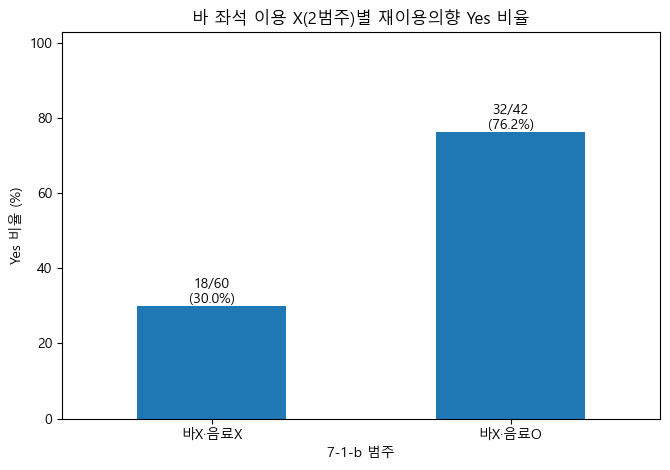

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

col_b = "reserve_service_used"
col_c = "reserve_service_reuse_flag"
yes_values = ["Yes", "YES", "yes", "예", "Y", "True", "1"]

# 바X 2범주만 (너가 원한 파랑/빨강)
target_b = [
    "리저브 전용 서비스를 이용하지 않음 (바 좌석 이용 X , 전용 음료 X)",
    "리저브 전용 음료만 이용함 (바 좌석 이용 X , 전용 음료만 O)"
]

sub = df[df[col_b].isin(target_b)].copy()
sub = sub.dropna(subset=[col_c]).copy()

# ✅ 0/1 변수 먼저 만들기 (핵심)
sub["reuse_yes"] = sub[col_c].isin(yes_values).astype(int)

# ✅ groupby-agg로 안정적으로 집계 (KeyError 절대 안 남)
grp = (
    sub.groupby(col_b)["reuse_yes"]
       .agg(n="count", yes="sum", yes_rate=lambda s: s.mean()*100)
       .reset_index()
)
grp["yes_rate"] = grp["yes_rate"].round(1)

print("[바X 2범주 각각의 Yes 비율]")
display(grp)

# 라벨 짧게
label_map = {
    target_b[0]: "바X·음료X",
    target_b[1]: "바X·음료O"
}
grp["label_short"] = grp[col_b].map(label_map)

ax = grp.set_index("label_short")["yes_rate"].plot(kind="bar", figsize=(6.8, 4.8), rot=0)
plt.title("바 좌석 이용 X(2범주)별 재이용의향 Yes 비율")
plt.xlabel("7-1-b 범주")
plt.ylabel("Yes 비율 (%)")

ymax = grp["yes_rate"].max()
ax.set_ylim(0, ymax * 1.35 if ymax > 0 else 1)

for i, row in enumerate(grp.itertuples(index=False)):
    ax.text(i, row.yes_rate, f"{int(row.yes)}/{int(row.n)}\n({row.yes_rate:.1f}%)",
            ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

✅ df50 로드 완료: C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7.csv / shape=(102342, 20)
✅ df30 로드 완료: C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7_30.csv / shape=(101373, 20)


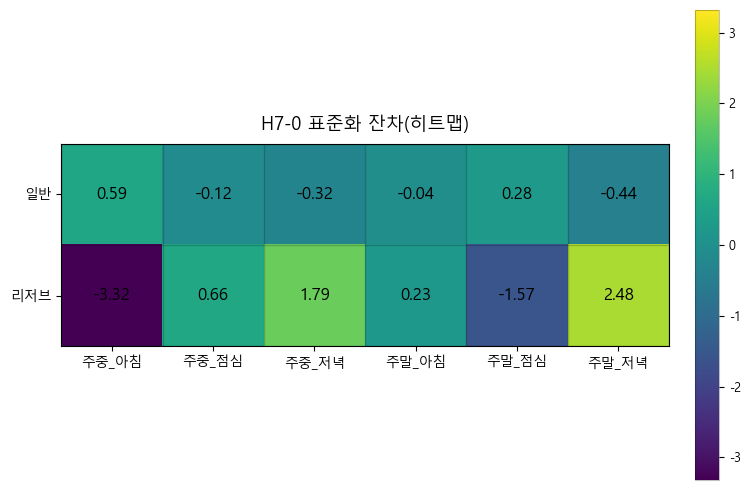

In [76]:
import os
import pandas as pd

PATH_REF50 = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7.csv"
PATH_REF30 = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\refined_h7_30.csv"

ALT_REF50 = "/mnt/data/refined_h7.csv"
ALT_REF30 = "/mnt/data/refined_h7_30.csv"

def load_csv_fallback(primary_path, alt_path=None, name="data"):
    for p in [primary_path, alt_path]:
        if p and os.path.exists(p):
            df = pd.read_csv(p, encoding="utf-8-sig")
            print(f"✅ {name} 로드 완료: {p} / shape={df.shape}")
            return df
    raise FileNotFoundError(f"{name} 파일을 찾을 수 없음:\n- {primary_path}\n- {alt_path}")

df50 = load_csv_fallback(PATH_REF50, ALT_REF50, name="df50")
df30 = load_csv_fallback(PATH_REF30, ALT_REF30, name="df30")

viz_h7_0(chi50, title_prefix="H7-0")

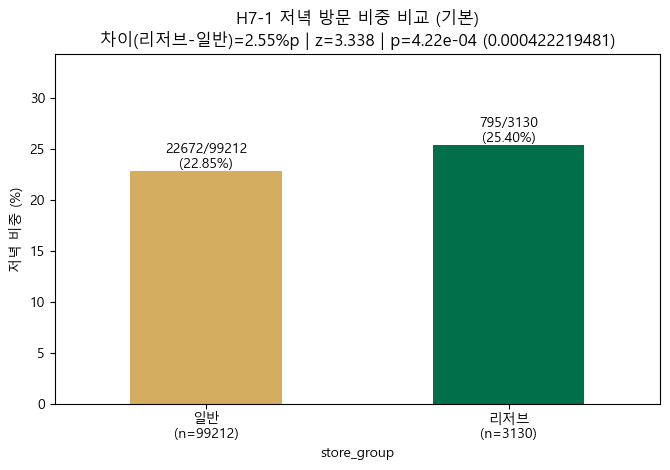

[기본] H7-1 결과
일반 저녁 비중:  22672/99212 = 22.85%
리저브 저녁 비중:795/3130 = 25.40%
차이(리저브-일반) = 2.55%p
z = 3.3378, p(단측, 리저브>일반) = 4.222194810087e-04
✅ 결론: H7-1 지지 (리저브의 저녁 비중이 일반보다 유의하게 높음)


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import platform

# 한글 폰트
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

STARBUCKS_GREEN = "#00704A"
STARBUCKS_GOLD  = "#D4AD60"

def h7_1_evening_plot_and_test(df, name="dataset", alpha=0.05):
    """
    H7-1: 리저브 매장은 일반 매장 대비 저녁 방문 비중이 더 높다.
    - 2표본 비율검정(단측: 리저브 > 일반)
    - 그래프: 저녁 비율만(일반 vs 리저브) → H7-0 히트맵과 겹침 최소화
    """

    d = df.copy()

    # 표준화
    d["store_group"] = d["store_group"].astype(str).str.strip().replace({
        "general":"일반", "reserve":"리저브",
        "일반 매장":"일반", "리저브 매장":"리저브"
    })
    d["visit_time"] = d["visit_time"].astype(str).str.strip().replace({
        "오전":"아침","AM":"아침","am":"아침","morning":"아침",
        "오후":"점심","lunch":"점심","afternoon":"점심",
        "밤":"저녁","PM":"저녁","pm":"저녁","dinner":"저녁","evening":"저녁"
    })

    # is_evening 없으면 생성
    if "is_evening" not in d.columns:
        d["is_evening"] = (d["visit_time"] == "저녁").astype(int)

    # 집계
    agg = d.groupby("store_group")["is_evening"].agg(["sum","count"]).reindex(["일반","리저브"])
    succ_gen, n_gen = float(agg.loc["일반","sum"]), float(agg.loc["일반","count"])
    succ_res, n_res = float(agg.loc["리저브","sum"]), float(agg.loc["리저브","count"])

    p_gen = succ_gen/n_gen
    p_res = succ_res/n_res
    diff_pp = (p_res - p_gen) * 100

    # 단측 검정(리저브 > 일반)
    z, p_one = proportions_ztest(
        count=np.array([succ_res, succ_gen]),
        nobs=np.array([n_res, n_gen]),
        alternative="larger"
    )
    p_one = float(p_one)

    # p 표기
    p_sci = f"{p_one:.2e}"
    p_dec = f"{p_one:.12f}"

    # 그래프용 데이터
    plot_pct = pd.Series({
        f"일반\n(n={int(n_gen)})": p_gen*100,
        f"리저브\n(n={int(n_res)})": p_res*100
    })

    ax = plot_pct.plot(kind="bar", figsize=(6.8, 4.8), rot=0,
                       color=[STARBUCKS_GOLD, STARBUCKS_GREEN])
    plt.title(
        f"H7-1 저녁 방문 비중 비교 ({name})\n"
        f"차이(리저브-일반)={diff_pp:.2f}%p | z={z:.3f} | p={p_sci} ({p_dec})"
    )
    plt.xlabel("store_group")
    plt.ylabel("저녁 비중 (%)")

    ymax = plot_pct.max()
    ax.set_ylim(0, ymax*1.35 if ymax>0 else 1)

    # 라벨: n명/전체 + %
    for i, (lab, val) in enumerate(plot_pct.items()):
        # 각 그룹의 저녁 성공수
        x = int(succ_gen) if "일반" in lab else int(succ_res)
        n = int(n_gen) if "일반" in lab else int(n_res)
        ax.text(i, val, f"{x}/{n}\n({val:.2f}%)", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

    # 결론 출력
    print("="*70)
    print(f"[{name}] H7-1 결과")
    print("="*70)
    print(f"일반 저녁 비중:  {succ_gen:.0f}/{n_gen:.0f} = {p_gen*100:.2f}%")
    print(f"리저브 저녁 비중:{succ_res:.0f}/{n_res:.0f} = {p_res*100:.2f}%")
    print(f"차이(리저브-일반) = {diff_pp:.2f}%p")
    print(f"z = {z:.4f}, p(단측, 리저브>일반) = {p_one:.12e}")

    if p_one < alpha and diff_pp > 0:
        print("✅ 결론: H7-1 지지 (리저브의 저녁 비중이 일반보다 유의하게 높음)")
    elif diff_pp > 0:
        print("⚠️ 결론: 리저브가 더 높긴 하나 유의하다고 보기 어려움(경향)")
    else:
        print("❌ 결론: 가설 반대 또는 차이 거의 없음")

    return {"p_gen":p_gen, "p_res":p_res, "diff_pp":diff_pp, "z":float(z), "p_one":p_one}

# 실행
out50 = h7_1_evening_plot_and_test(df50, name="기본")

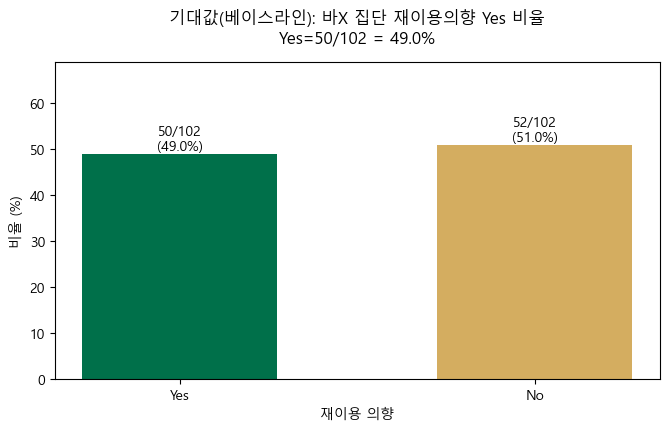

✅ 베이스라인(바X 집단): Yes=50/102 = 49.0%


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

# 한글 폰트(깨짐 방지)
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

STARBUCKS_GREEN = "#00704A"
STARBUCKS_GOLD  = "#D4AD60"

def plot_baseline_yes_no(df_survey):
    col_b = "reserve_service_used"
    col_c = "reserve_service_reuse_flag"
    yes_values = ["Yes", "YES", "yes", "예", "Y", "True", "1"]

    target_b = [
        "리저브 전용 서비스를 이용하지 않음 (바 좌석 이용 X , 전용 음료 X)",
        "리저브 전용 음료만 이용함 (바 좌석 이용 X , 전용 음료만 O)"
    ]

    sub = df_survey[df_survey[col_b].isin(target_b)].dropna(subset=[col_c]).copy()
    sub["reuse_yes"] = sub[col_c].isin(yes_values).astype(int)

    n = len(sub)
    yes = int(sub["reuse_yes"].sum())
    no = n - yes
    yes_rate = yes / n * 100
    no_rate = no / n * 100

    labels = ["Yes", "No"]
    rates = [yes_rate, no_rate]
    counts = [yes, no]
    colors = [STARBUCKS_GREEN, STARBUCKS_GOLD]

    fig, ax = plt.subplots(figsize=(6.8, 4.8))
    bars = ax.bar(labels, rates, color=colors, width=0.55)

    # ✅ p̂ 제거(헷갈림 방지)
    ax.set_title(
        "기대값(베이스라인): 바X 집단 재이용의향 Yes 비율\n"
        f"Yes={yes}/{n} = {yes_rate:.1f}%",
        pad=14
    )
    ax.set_xlabel("재이용 의향")
    ax.set_ylabel("비율 (%)")

    ymax = max(rates)
    ax.set_ylim(0, ymax * 1.35 if ymax > 0 else 1)

    for b, c, r in zip(bars, counts, rates):
        ax.text(
            b.get_x() + b.get_width()/2, r,
            f"{c}/{n}\n({r:.1f}%)",
            ha="center", va="bottom", fontsize=10
        )

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    print(f"✅ 베이스라인(바X 집단): Yes={yes}/{n} = {yes_rate:.1f}%")
    return {"n": n, "yes": yes, "no": no, "yes_rate": yes_rate}

# 실행
baseline = plot_baseline_yes_no(df)

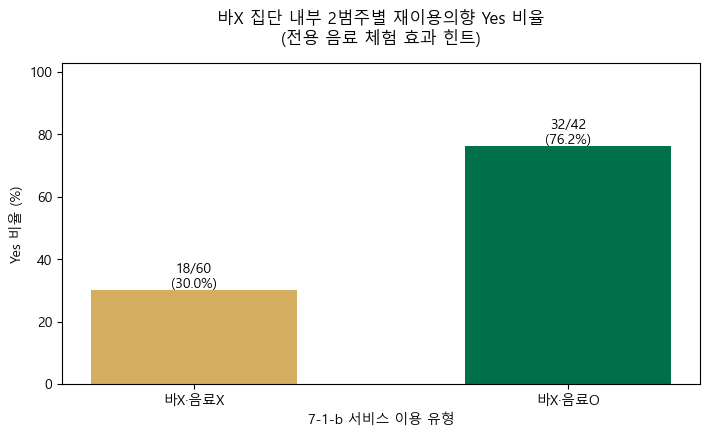

,label_short,n,yes,yes_rate
0,바X·음료X,60,18,30.0
1,바X·음료O,42,32,76.2


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STARBUCKS_GREEN = "#00704A"
STARBUCKS_GOLD  = "#D4AD60"

def plot_two_category_yes_rate(df_survey):
    col_b = "reserve_service_used"
    col_c = "reserve_service_reuse_flag"
    yes_values = ["Yes", "YES", "yes", "예", "Y", "True", "1"]

    target_b = [
        "리저브 전용 서비스를 이용하지 않음 (바 좌석 이용 X , 전용 음료 X)",
        "리저브 전용 음료만 이용함 (바 좌석 이용 X , 전용 음료만 O)"
    ]

    sub = df_survey[df_survey[col_b].isin(target_b)].dropna(subset=[col_c]).copy()
    sub["reuse_yes"] = sub[col_c].isin(yes_values).astype(int)

    grp = (
        sub.groupby(col_b)["reuse_yes"]
           .agg(n="count", yes="sum", yes_rate=lambda s: s.mean()*100)
           .reset_index()
    )
    grp["yes_rate"] = grp["yes_rate"].round(1)

    label_map = {
        target_b[0]: "바X·음료X",
        target_b[1]: "바X·음료O"
    }
    grp["label_short"] = grp[col_b].map(label_map)

    # 그래프
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    colors = [STARBUCKS_GOLD, STARBUCKS_GREEN]  # 체험 있는 쪽을 초록으로 강조하고 싶으면 이 순서 유지
    bars = ax.bar(grp["label_short"], grp["yes_rate"], color=colors, width=0.55)

    ax.set_title("바X 집단 내부 2범주별 재이용의향 Yes 비율\n(전용 음료 체험 효과 힌트)", pad=14)
    ax.set_xlabel("7-1-b 서비스 이용 유형")
    ax.set_ylabel("Yes 비율 (%)")

    ymax = grp["yes_rate"].max()
    ax.set_ylim(0, ymax*1.35 if ymax>0 else 1)

    for b, row in zip(bars, grp.itertuples(index=False)):
        ax.text(
            b.get_x()+b.get_width()/2, row.yes_rate,
            f"{int(row.yes)}/{int(row.n)}\n({row.yes_rate:.1f}%)",
            ha="center", va="bottom", fontsize=10
        )

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    display(grp[["label_short","n","yes","yes_rate"]])
    return grp

# 실행:
grp = plot_two_category_yes_rate(df)   # df = survey_response

In [80]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

# =========================================
# H7-1: 2표본 비율검정 (단측: 리저브 > 일반)
# + 효과크기(Cohen's h) 추가
# =========================================

def h7_1_evening_prop_test(df, group_col="store_group", alpha=0.05, show_plot=True):
    d = df.copy()

    # -----------------------------
    # 0) 값 표준화
    # -----------------------------
    d[group_col] = d[group_col].astype(str).str.strip().replace({
        "general": "일반", "reserve": "리저브",
        "일반 매장": "일반", "리저브 매장": "리저브"
    })

    if "is_evening" not in d.columns:
        if "visit_time" not in d.columns:
            raise KeyError("is_evening도 없고 visit_time도 없습니다.")
        d["visit_time"] = d["visit_time"].astype(str).str.strip().replace({
            "오전":"아침","AM":"아침","am":"아침","morning":"아침",
            "오후":"점심","lunch":"점심","afternoon":"점심",
            "밤":"저녁","PM":"저녁","pm":"저녁","dinner":"저녁","evening":"저녁"
        })
        d["is_evening"] = (d["visit_time"] == "저녁").astype(int)

    # -----------------------------
    # 1) 그룹별 성공수/전체수
    # -----------------------------
    agg = d.groupby(group_col)["is_evening"].agg(["sum", "count"]).reindex(["일반", "리저브"])

    if agg.isna().any().any():
        raise ValueError("일반/리저브 그룹 매핑 실패. store_group 값 확인 필요.")

    succ_gen = float(agg.loc["일반", "sum"])
    n_gen    = float(agg.loc["일반", "count"])
    succ_res = float(agg.loc["리저브", "sum"])
    n_res    = float(agg.loc["리저브", "count"])

    # -----------------------------
    # 2) 비율, 차이(%p)
    # -----------------------------
    p_gen = succ_gen / n_gen
    p_res = succ_res / n_res
    diff_pp = (p_res - p_gen) * 100

    # -----------------------------
    # 3) 2표본 비율검정 (단측: 리저브 > 일반)
    # -----------------------------
    z_stat, p_one = proportions_ztest(
        count=np.array([succ_res, succ_gen], dtype=float),
        nobs=np.array([n_res, n_gen], dtype=float),
        alternative="larger"
    )

    # -----------------------------
    # 4) 효과크기: Cohen's h
    # h = 2*arcsin(sqrt(p1)) - 2*arcsin(sqrt(p2))
    # -----------------------------
    cohen_h = 2 * np.arcsin(np.sqrt(p_res)) - 2 * np.arcsin(np.sqrt(p_gen))

    # 해석용 라벨
    abs_h = abs(cohen_h)
    if abs_h < 0.2:
        h_interp = "매우 작음"
    elif abs_h < 0.5:
        h_interp = "작음"
    elif abs_h < 0.8:
        h_interp = "중간"
    else:
        h_interp = "큼"

    # -----------------------------
    # 5) 출력
    # -----------------------------
    print("="*75)
    print("H7-1 검정: 리저브 매장은 일반 대비 '저녁 비중'이 더 높다")
    print("="*75)
    print(f"일반:  저녁 {int(succ_gen)}/{int(n_gen)} = {p_gen*100:.2f}%")
    print(f"리저브: 저녁 {int(succ_res)}/{int(n_res)} = {p_res*100:.2f}%")
    print(f"차이(리저브-일반) = {diff_pp:.2f}%p")
    print(f"z = {float(z_stat):.4f}")
    print(f"p-value(소수) = {float(p_one):.12f}")
    print(f"p-value(과학적) = {float(p_one):.2e}")
    print(f"Cohen's h = {float(cohen_h):.3f} ({h_interp})")

    if p_one < alpha and diff_pp > 0:
        print("✅ 결론: 리저브의 저녁 비중이 일반보다 유의하게 높음")
    elif diff_pp > 0:
        print("⚠️ 결론: 리저브가 더 높지만 유의하다고 보기 어려움")
    else:
        print("❌ 결론: 가설 반대(리저브 ≤ 일반)")

    return {
        "general_rate_pct": round(p_gen * 100, 2),
        "reserve_rate_pct": round(p_res * 100, 2),
        "diff_pp": round(diff_pp, 2),
        "z": float(z_stat),
        "p_one": float(p_one),
        "cohen_h": float(cohen_h),
        "cohen_h_interp": h_interp,
        "n_general": int(n_gen),
        "n_reserve": int(n_res)
    }

# 실행
result_h7_1 = h7_1_evening_prop_test(df50, show_plot=False)

H7-1 검정: 리저브 매장은 일반 대비 '저녁 비중'이 더 높다
일반:  저녁 22672/99212 = 22.85%
리저브: 저녁 795/3130 = 25.40%
차이(리저브-일반) = 2.55%p
z = 3.3378
p-value(소수) = 0.000422219481
p-value(과학적) = 4.22e-04
Cohen's h = 0.060 (매우 작음)
✅ 결론: 리저브의 저녁 비중이 일반보다 유의하게 높음
